EDA FOR ACN DATASET

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
plt.style.use("default")
print("Libraries Loaded")

Libraries Loaded


In [45]:
C_GREEN  = "#2d6a4f"
C_ORANGE = "#e07b39"
C_BLUE   = "#1e6091"
C_RED    = "#c1121f"
C_GREY   = "#6c757d"

In [46]:
acn_df = pd.read_csv(r"C:\Users\saeek\Downloads\socbiz\data\acn_clean.csv", parse_dates=["connectionTime","disconnectTime", "doneChargingTime"])
print(f"  ACN    : {len(df_acn):,} sessions")
                                                          


  ACN    : 16,304 sessions


In [47]:
acn_df["connectionTime"] = pd.to_datetime(acn_df["connectionTime"])
acn_df["disconnectTime"] = pd.to_datetime(acn_df["disconnectTime"])

In [48]:
acn_df["hour"] = acn_df["connectionTime"].dt.hour
acn_df["day"] = acn_df["connectionTime"].dt.day
acn_df["month"] = acn_df["connectionTime"].dt.month
acn_df["weekday"] = acn_df["connectionTime"].dt.day_name()

In [54]:
acn_df["session_duration_hours"] = ((acn_df["disconnectTime"]-acn_df["connectionTime"]).dt.total_seconds())/3600
acn_df["charging_duration_hours"] = (acn_df["doneChargingTime"]-acn_df["connectionTime"]).dt.total_seconds() / 3600
acn_df["idle_time_hours"] = (acn_df["session_duration_hours"]-acn_df["charging_duration_hours"])

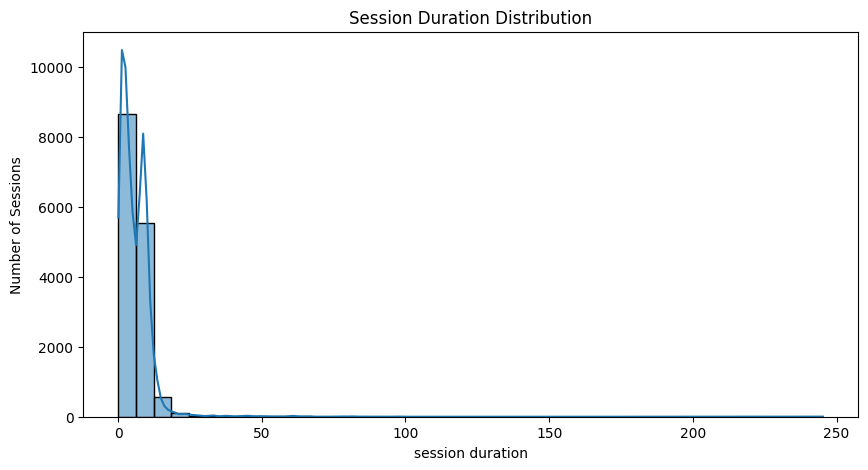

 Saved chart 1


<Figure size 640x480 with 0 Axes>

In [118]:
plt.figure(figsize=(10,5))

sns.histplot(
    acn_df["session_duration_hours"],
    bins=40,
    kde=True
)

plt.title("Session Duration Distribution")
plt.xlabel("session duration")
plt.ylabel("Number of Sessions")
plt.show()
plt.savefig("outputs/charts/01_session_duration_distribution", dpi=150, bbox_inches="tight")

print(" Saved chart 1")


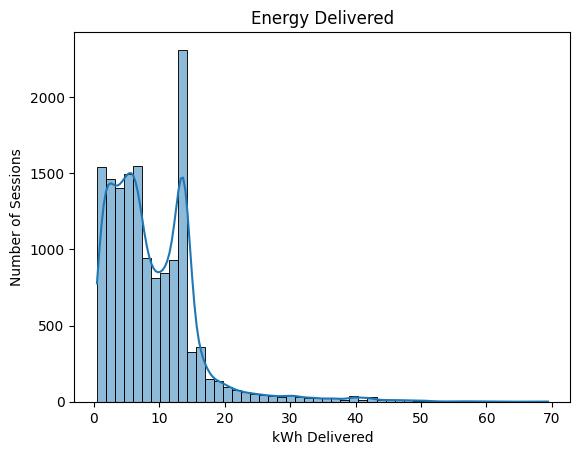

 Saved


<Figure size 640x480 with 0 Axes>

In [119]:
sns.histplot(
    acn_df["kWhDelivered"],
    bins=50,
    kde=True
)

plt.title("Energy Delivered")
plt.xlabel("kWh Delivered")
plt.ylabel("Number of Sessions")
plt.show()
plt.savefig("outputs/charts/02_energy_delivered", dpi=150, bbox_inches="tight")

print(" Saved")

 Saved 


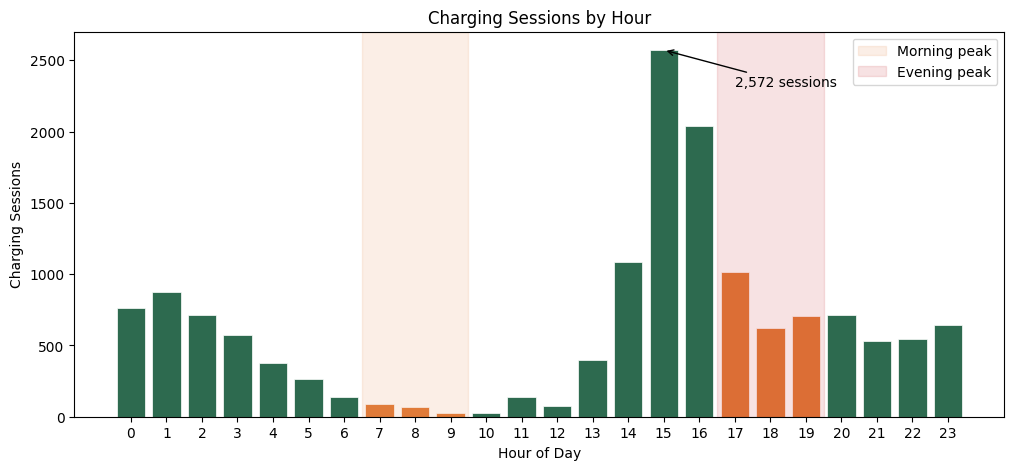

In [110]:
fig, ax = plt.subplots(figsize=(12, 5))

hourly = acn_df.groupby("hour")["sessionID"].count()

colors = [
    C_ORANGE if h in range(7, 10) or h in range(17, 20)
    else C_GREEN
    for h in hourly.index
]

ax.bar(
    hourly.index,
    hourly.values,
    color=colors,
    width=0.8,
    edgecolor="white",
    linewidth=0.5
)


ax.axvspan(6.5, 9.5, alpha=0.12, color=C_ORANGE,
           label="Morning peak")
ax.axvspan(16.5, 19.5, alpha=0.12, color=C_RED,
           label="Evening peak")

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Charging Sessions")
ax.set_title("Charging Sessions by Hour")

ax.set_xticks(range(24))
ax.legend()


peak_hour = hourly.idxmax()

ax.annotate(
    f"{hourly.max():,} sessions",
    xy=(peak_hour, hourly.max()),
    xytext=(peak_hour + 2, hourly.max() * 0.9),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.savefig("outputs/charts/03_acn_hourly_sessions.png", dpi=150)

print(" Saved ")

In [59]:
print(acn_df.columns.tolist())

['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1', 'hour', 'day', 'month', 'weekday', 'session_duration_hours', 'charging_duration_hours', 'idle_time_hours']


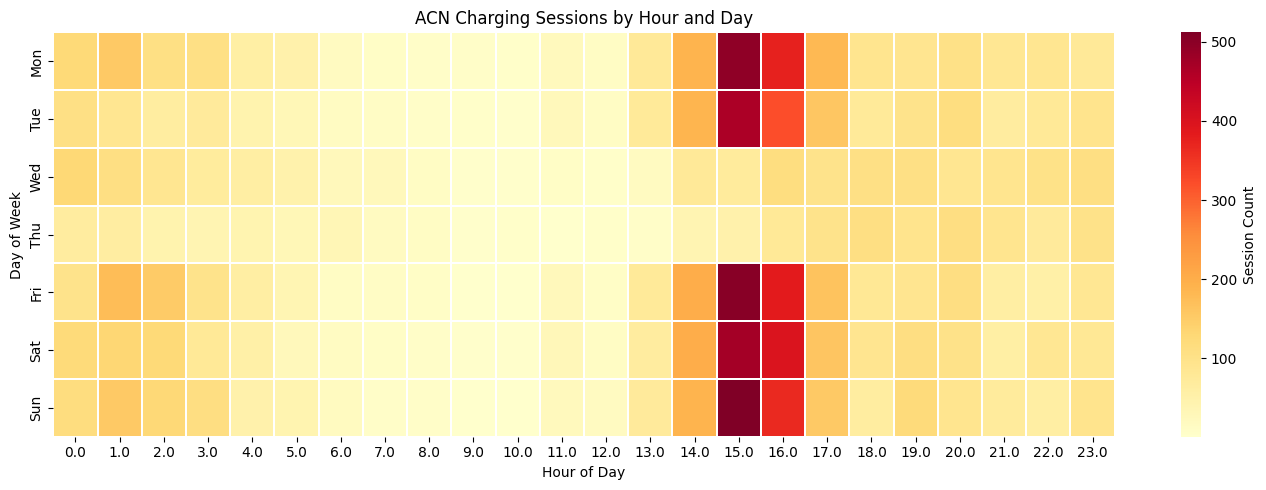

 Saved chart 04


<Figure size 640x480 with 0 Axes>

In [111]:
fig, ax = plt.subplots(figsize=(14, 5))

pivot = acn_df.pivot_table(
    index="weekday",
    columns="hour",
    values="sessionID",
    aggfunc="count"
)

pivot.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

sns.heatmap(
    pivot,
    ax=ax,
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "Session Count"}
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Day of Week")
ax.set_title("ACN Charging Sessions by Hour and Day")

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/04_acn_heatmap_hour_day.png", dpi=150)

print(" Saved chart 04")



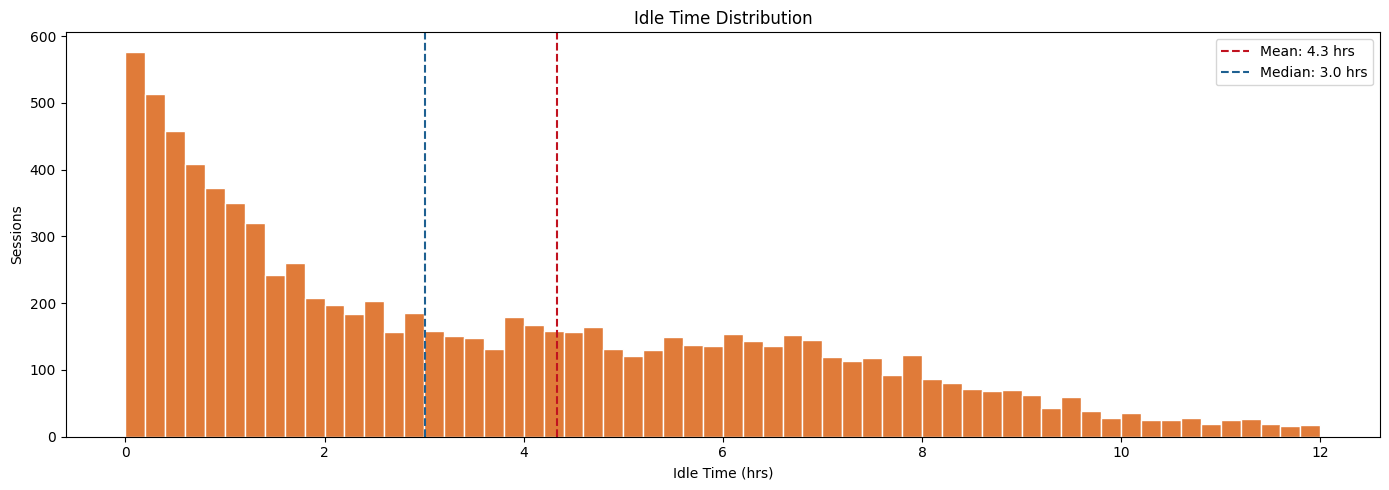

 Saved chart 5


<Figure size 640x480 with 0 Axes>

In [112]:
fig, ax = plt.subplots(figsize=(14, 5))

idle_data = acn_df[acn_df["idle_time_hours"] > 0.05]["idle_time_hours"]

ax.hist(idle_data,bins=60,color=C_ORANGE,edgecolor="white",range=(0, 12))

ax.axvline(
    idle_data.mean(),color=C_RED,linestyle="--",label=f"Mean: {idle_data.mean():.1f} hrs"
)

ax.axvline(idle_data.median(),color=C_BLUE,linestyle="--",label=f"Median: {idle_data.median():.1f} hrs"
)

ax.set_xlabel("Idle Time (hrs)")
ax.set_ylabel("Sessions")
ax.set_title("Idle Time Distribution")
ax.legend()


plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/5_acn_idle_time.png", dpi=150, bbox_inches="tight")

print(" Saved chart 5")

In [70]:
def peak_label(hour):

    if 7 <= hour <= 10:
        return "Morning Peak"

    elif 17 <= hour <= 21:
        return "Evening Peak"

    else:
        return "Off-Peak"

acn_df["peak_period"] = (
    acn_df["hour"].apply(peak_label)
)

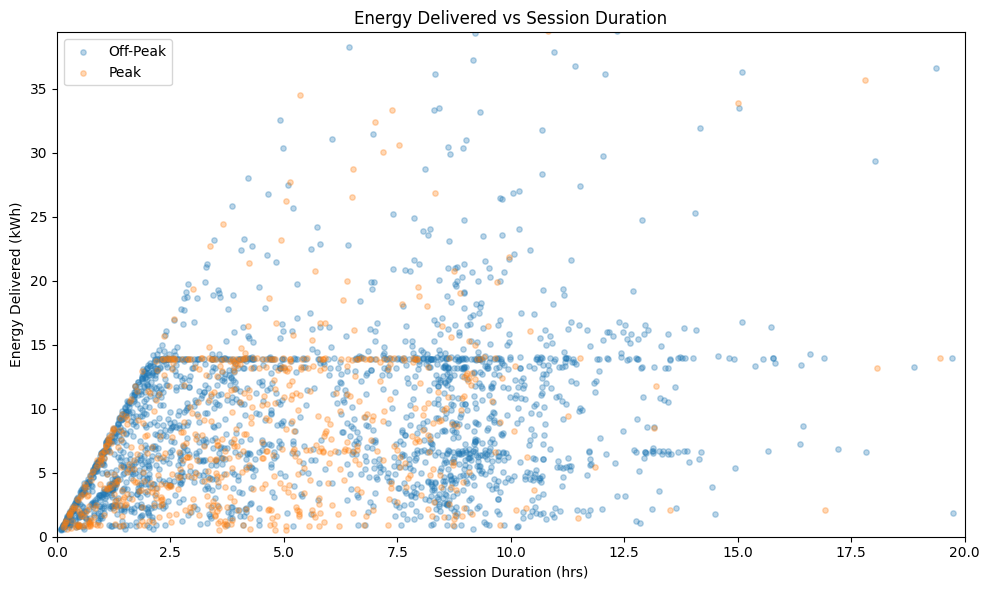

 Saved chart 06


In [113]:
fig, ax = plt.subplots(figsize=(10, 6))

offpeak = sample[sample["peak_period"] == "Off-Peak"]
peak = sample[sample["peak_period"] != "Off-Peak"]

ax.scatter(
    offpeak["session_duration_hours"],
    offpeak["kWhDelivered"],
    alpha=0.3,
    s=15,
    label="Off-Peak"
)

ax.scatter(
    peak["session_duration_hours"],
    peak["kWhDelivered"],
    alpha=0.3,
    s=15,
    label="Peak"
)

ax.set_xlabel("Session Duration (hrs)")
ax.set_ylabel("Energy Delivered (kWh)")
ax.set_title("Energy Delivered vs Session Duration")
ax.set_xlim(0, 20)
ax.set_ylim(0, acn_df["kWhDelivered"].quantile(0.99))

ax.legend()

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/06_acn_kwh_vs_duration.png", dpi=150)
plt.close()
print(" Saved chart 06")

URBAN EV DATASET

In [78]:
urban_df = pd.read_csv(
    r"C:\Users\saeek\Downloads\socbiz\notebooks\urbanev_cleaned_processed.csv"
)

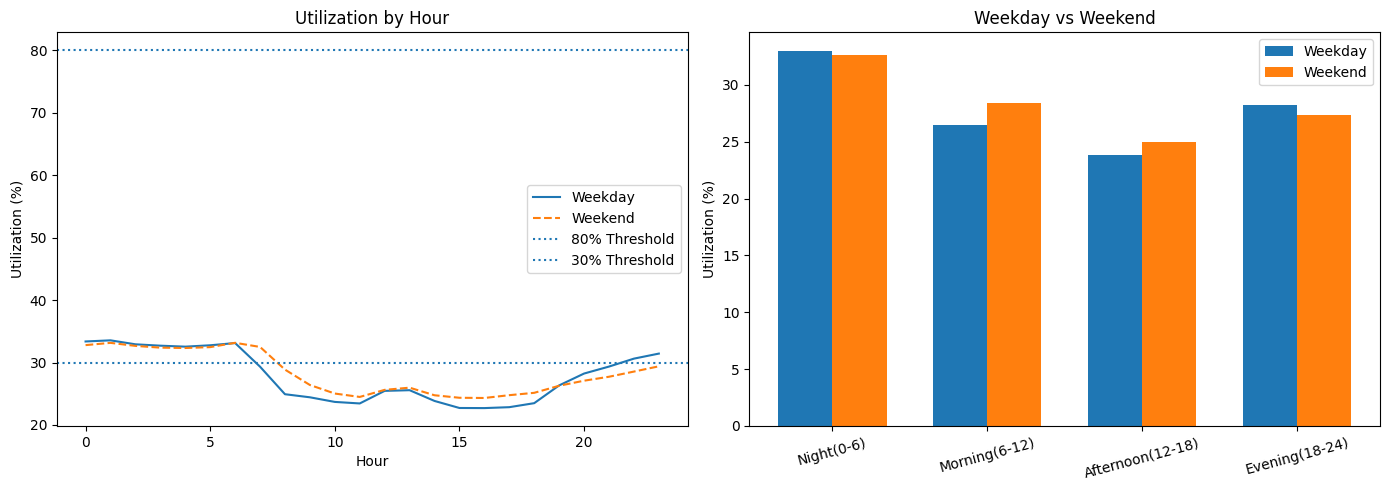

  Saved chart 07


<Figure size 640x480 with 0 Axes>

In [114]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weekday = urban_df[urban_df["is_weekend"] == 0]
weekend = urban_df[urban_df["is_weekend"] == 1]

wd_hourly = weekday.groupby("hour_of_day")["utilization_rate"].mean() * 100
we_hourly = weekend.groupby("hour_of_day")["utilization_rate"].mean() * 100

ax = axes[0]

ax.plot(wd_hourly.index, wd_hourly.values, label="Weekday")
ax.plot(we_hourly.index, we_hourly.values, "--", label="Weekend")

ax.axhline(80, linestyle=":", label="80% Threshold")
ax.axhline(30, linestyle=":", label="30% Threshold")

ax.set_xlabel("Hour")
ax.set_ylabel("Utilization (%)")
ax.set_title("Utilization by Hour")
ax.legend()

slot_order = ["Night(0-6)", "Morning(6-12)", "Afternoon(12-18)", "Evening(18-24)"]

wd_slots = weekday.groupby("time_slot")["utilization_rate"].mean() * 100
we_slots = weekend.groupby("time_slot")["utilization_rate"].mean() * 100

x = np.arange(len(slot_order))
width = 0.35

ax = axes[1]

ax.bar(
    x - width/2,[wd_slots.get(s, 0) for s in slot_order],width,label="Weekday"
)

ax.bar(
    x + width/2,[we_slots.get(s, 0) for s in slot_order],width,label="Weekend"
)

ax.set_xticks(x)
ax.set_xticklabels(slot_order, rotation=15)
ax.set_ylabel("Utilization (%)")
ax.set_title("Weekday vs Weekend")
ax.legend()

plt.tight_layout()
plt.show()

plt.savefig("outputs/charts/07_urbanev_utilization_hour.png", dpi=150,
            bbox_inches="tight")

print("  Saved chart 07")

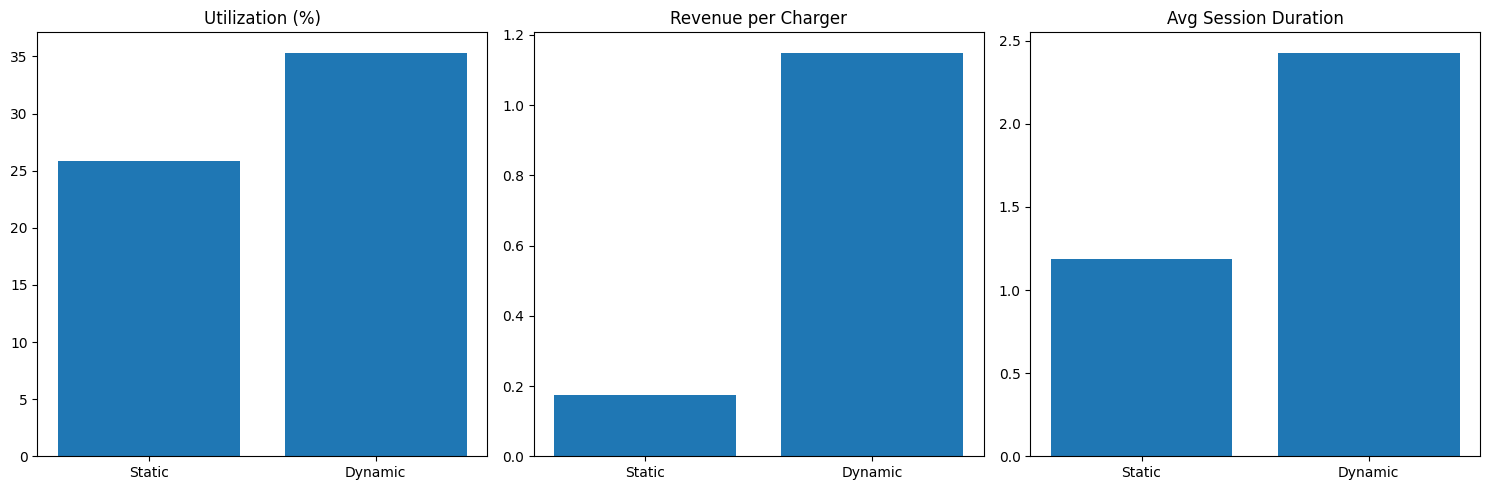

 Saved chart 08


<Figure size 640x480 with 0 Axes>

In [115]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

dynamic = urban_df[urban_df["pricing_regime"] == "dynamic"]
static = urban_df[urban_df["pricing_regime"] == "static"]

metrics = [
    ("utilization_rate", "Utilization (%)", 100),
    ("revenue_per_charger_cny", "Revenue per Charger", 1),
    ("avg_duration_hrs", "Avg Session Duration", 1)
]

for ax, (col, title, scale) in zip(axes, metrics):
    static_val = static[col].mean() * scale
    dynamic_val = dynamic[col].mean() * scale

    ax.bar(
        ["Static", "Dynamic"],
        [static_val, dynamic_val]
    )

    ax.set_title(title)

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/08_natural_experiment.png", dpi=150, bbox_inches="tight")

print(" Saved chart 08")

In [89]:

print(urban_df.columns.tolist())

['timestamp_id', 'district_id', 'occupancy', 'volume_kwh', 'price_cny_per_kwh', 'avg_duration_hrs', 'datetime', 'district_num', 'total_chargers', 'fast_count', 'slow_count', 'area', 'longitude', 'latitude', 'CBD', 'dynamic_pricing', 'hour_of_day', 'day_of_week', 'is_weekend', 'month', 'day_of_month', 'minute', 'hour_float', 'hour', 'peak_period', 'time_slot', 'utilization_rate', 'congestion_flag', 'underuse_flag', 'revenue_cny', 'revenue_per_charger_cny', 'pricing_regime', 'fast_charger_dominant', 'lag_1', 'lag_12', 'lag_288', 'rolling_3']


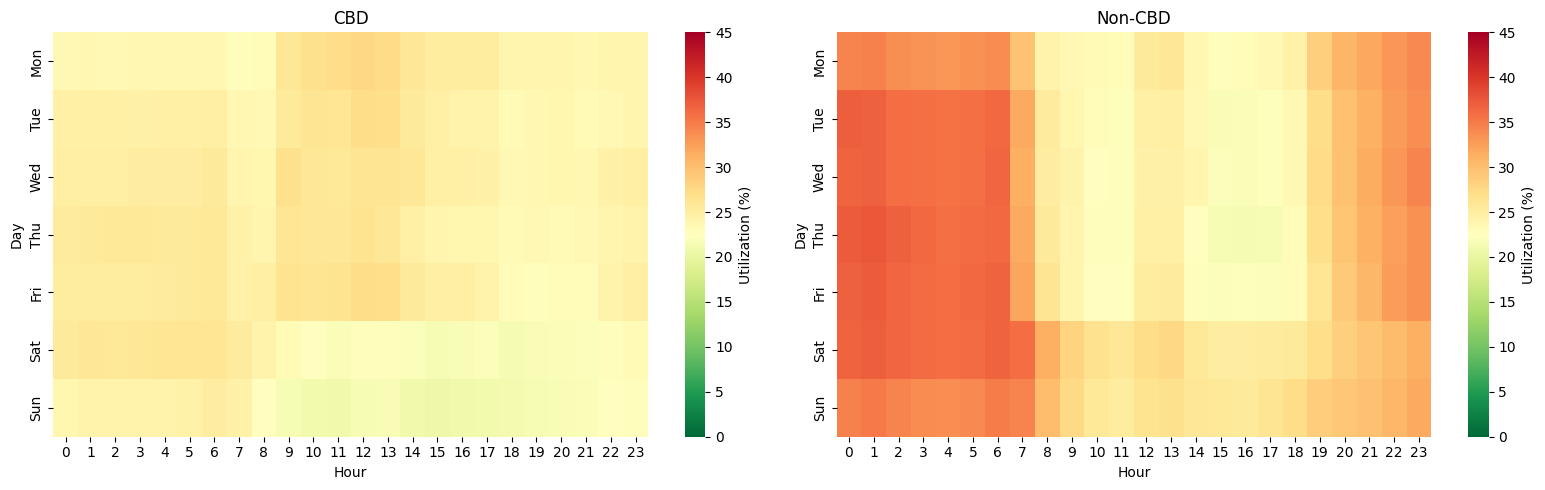

Saved chart 09


In [116]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (cbd, title) in zip(
    axes,
    [(1, "CBD"), (0, "Non-CBD")]
):

    data = urban_df[urban_df["CBD"] == cbd]

    heatmap_data = data.pivot_table(
        index="day_of_week", columns="hour_of_day",values="utilization_rate",aggfunc="mean"
    ) * 100

    heatmap_data.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

    sns.heatmap(
        heatmap_data,ax=ax,cmap="RdYlGn_r",vmin=0,vmax=45,cbar_kws={"label": "Utilization (%)"}
    )


    ax.set_xlabel("Hour")
    ax.set_ylabel("Day")
    ax.set_title(title)

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/09_congestion_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved chart 09")

In [103]:
print(urban_df["utilization_rate"].describe())

count    2.134080e+06
mean     2.802425e-01
std      1.760300e-01
min      0.000000e+00
25%      1.515152e-01
50%      2.500000e-01
75%      3.779070e-01
max      1.000000e+00
Name: utilization_rate, dtype: float64


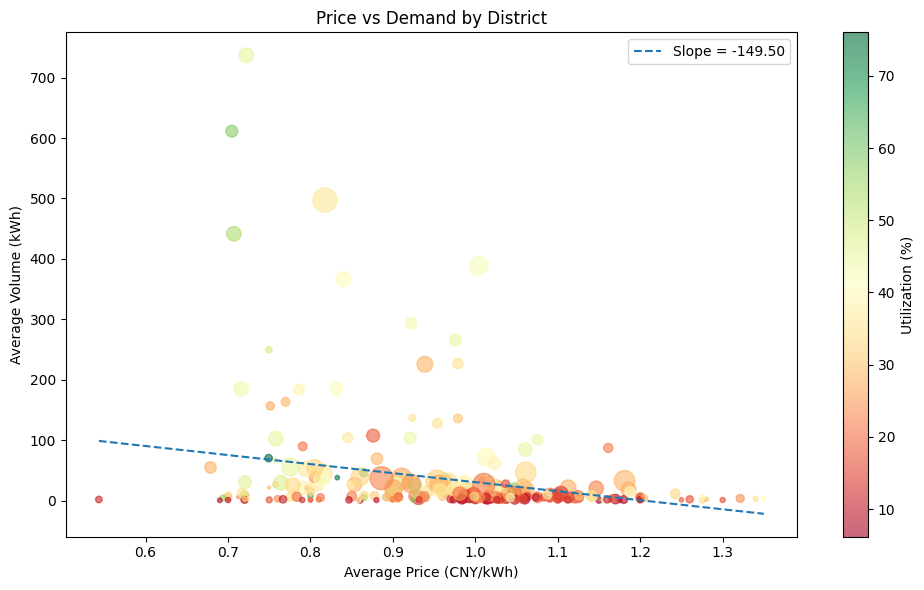

 Saved


In [117]:
fig, ax = plt.subplots(figsize=(10, 6))

district_agg = (
    urban_df.groupby("district_id")
    .agg(
        avg_price=("price_cny_per_kwh", "mean"),avg_volume=("volume_kwh", "mean"),avg_util=("utilization_rate", "mean"),chargers=("total_chargers", "first")
    ).reset_index()
)

district_agg = district_agg[district_agg["avg_volume"] > 0.01]

sc = ax.scatter(
    district_agg["avg_price"],
    district_agg["avg_volume"],c=district_agg["avg_util"] * 100,cmap="RdYlGn",
    s=district_agg["chargers"] * 0.8,alpha=0.6
)

plt.colorbar(sc, ax=ax, label="Utilization (%)")

z = np.polyfit(
    district_agg["avg_price"],district_agg["avg_volume"],1
)

x = np.linspace(
    district_agg["avg_price"].min(),
    district_agg["avg_price"].max(),
    100
)

ax.plot(x, np.poly1d(z)(x), "--", label=f"Slope = {z[0]:.2f}")

ax.set_xlabel("Average Price (CNY/kWh)")
ax.set_ylabel("Average Volume (kWh)")
ax.set_title("Price vs Demand by District")

ax.legend()

plt.tight_layout()
plt.show()
plt.savefig("outputs/charts/acn_utilization_dist.png", dpi=150)
plt.close()
print(" Saved")